In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Load raw MS Forms export (use latin-1 encoding — MS Forms CSVs often have special characters)
df = pd.read_csv('../reports/UAT_Responses_Raw.csv', encoding='latin-1')

print(f"Total responses: {len(df)}")
print(f"\nColumn count: {len(df.columns)}")
print(f"\nConsent check:")
print(df.iloc[:, 12].value_counts())  # adjust index if your consent column differs

Total responses: 8

Column count: 30

Consent check:
Before we begin  please read and confirm the following\n\nBy continuing you confirm that: - You have read the Participant Information Sheet - You understand taking part is voluntary - You can stop at a
Yes  I agree to take part    8
Name: count, dtype: int64


In [3]:
# Map word-scale answers to numbers
scale_map = {
    'Strongly agree': 5,
    'Agree': 4,
    'Neither agree nor disagree': 3,
    'Disagree': 2,
    'Strongly disagree': 1
}

# Adjust these column indices to match YOUR export (check with df.columns if different)
likert_col_indices = list(range(19, 28))  # columns 19-27 in your export
col_names = [
    'clarity_chart1', 'clarity_chart2', 'clarity_chart3',
    'trust_workplace', 'trust_confidence', 'trust_customer',
    'useful_explain', 'useful_errors', 'useful_recommend'
]

clean = pd.DataFrame()
clean['role'] = df.iloc[:, 13]
clean['experience'] = df.iloc[:, 14]

for idx, name in zip(likert_col_indices, col_names):
    clean[name] = df.iloc[:, idx].map(scale_map)

print("Cleaned data preview:")
print(clean.head())

Cleaned data preview:
                        role         experience  clarity_chart1  \
0       Supply Chain Analyst       2 to 5 years               5   
1         Compliance Officer       2 to 5 years               4   
2  Banking / Finance Manager       2 to 5 years               5   
3     Financial Data Analyst  Less than 2 years               5   
4     Financial Data Analyst       2 to 5 years               5   

   clarity_chart2  clarity_chart3  trust_workplace  trust_confidence  \
0               5               5                5                 4   
1               4               4                4                 4   
2               4               4                4                 4   
3               5               5                5                 5   
4               4               5                5                 5   

   trust_customer  useful_explain  useful_errors  useful_recommend  
0               4               4              4                 4  
1   

In [4]:
clarity_cols = ['clarity_chart1', 'clarity_chart2', 'clarity_chart3']
trust_cols   = ['trust_workplace', 'trust_confidence', 'trust_customer']
useful_cols  = ['useful_explain', 'useful_errors', 'useful_recommend']
all_likert   = clarity_cols + trust_cols + useful_cols

clarity_mean = clean[clarity_cols].mean(axis=1).mean()
trust_mean   = clean[trust_cols].mean(axis=1).mean()
useful_mean  = clean[useful_cols].mean(axis=1).mean()
overall_mean = clean[all_likert].mean().mean()

print("=" * 50)
print("TABLE 4: UAT LIKERT SCORE RESULTS")
print("=" * 50)
print(f"n = {len(clean)} participants")
print(f"\nClarity:    {clarity_mean:.2f}/5.00")
print(f"Trust:      {trust_mean:.2f}/5.00")
print(f"Usefulness: {useful_mean:.2f}/5.00")
print(f"Overall:    {overall_mean:.2f}/5.00")

print(f"\nIndividual question means:")
for col in all_likert:
    print(f"  {col:<20} {clean[col].mean():.2f} (std={clean[col].std():.2f})")

print(f"\nParticipant roles:")
print(clean['role'].value_counts())
print(f"\nExperience levels:")
print(clean['experience'].value_counts())

TABLE 4: UAT LIKERT SCORE RESULTS
n = 8 participants

Clarity:    4.58/5.00
Trust:      4.54/5.00
Usefulness: 4.42/5.00
Overall:    4.51/5.00

Individual question means:
  clarity_chart1       4.88 (std=0.35)
  clarity_chart2       4.25 (std=0.46)
  clarity_chart3       4.62 (std=0.52)
  trust_workplace      4.75 (std=0.46)
  trust_confidence     4.62 (std=0.52)
  trust_customer       4.25 (std=1.04)
  useful_explain       4.00 (std=0.93)
  useful_errors        4.62 (std=0.52)
  useful_recommend     4.62 (std=0.52)

Participant roles:
role
 Financial Data Analyst      2
Credit Risk Analyst          2
Supply Chain Analyst         1
Compliance Officer           1
Banking / Finance Manager    1
Finance graduate             1
Name: count, dtype: int64

Experience levels:
experience
2 to 5 years         5
Less than 2 years    3
Name: count, dtype: int64


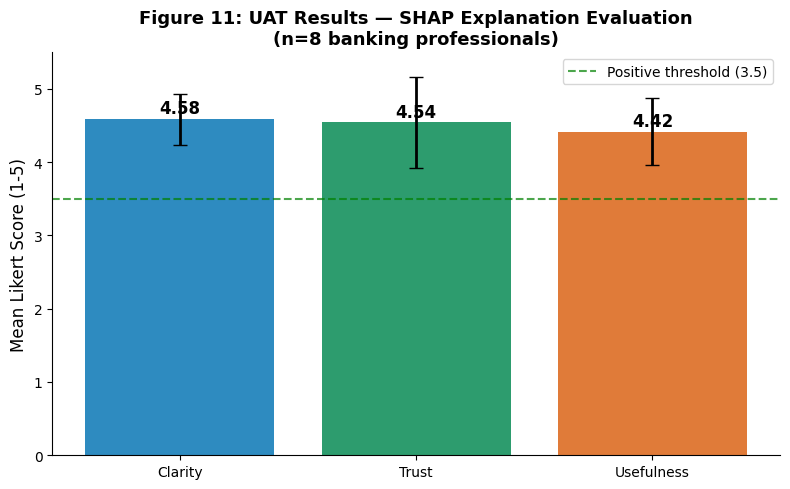

Saved: shap_plots/uat_dimension_scores.png


In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

dimensions = ['Clarity', 'Trust', 'Usefulness']
scores = [clarity_mean, trust_mean, useful_mean]
colors = ['#2E8BC0', '#2D9C6E', '#E07B39']
errors = [
    clean[clarity_cols].mean(axis=1).std(),
    clean[trust_cols].mean(axis=1).std(),
    clean[useful_cols].mean(axis=1).std()
]

bars = ax.bar(dimensions, scores, color=colors, yerr=errors, capsize=5,
              error_kw={'linewidth': 2, 'color': 'black'})
ax.axhline(y=3.5, color='green', linestyle='--', alpha=0.7,
           label='Positive threshold (3.5)')

for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.08,
            f'{score:.2f}', ha='center', fontsize=12, fontweight='bold')

ax.set_ylim(0, 5.5)
ax.set_ylabel('Mean Likert Score (1-5)', fontsize=12)
ax.set_title(f'Figure 11: UAT Results — SHAP Explanation Evaluation\n(n={len(clean)} banking professionals)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../shap_plots/uat_dimension_scores.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: shap_plots/uat_dimension_scores.png")

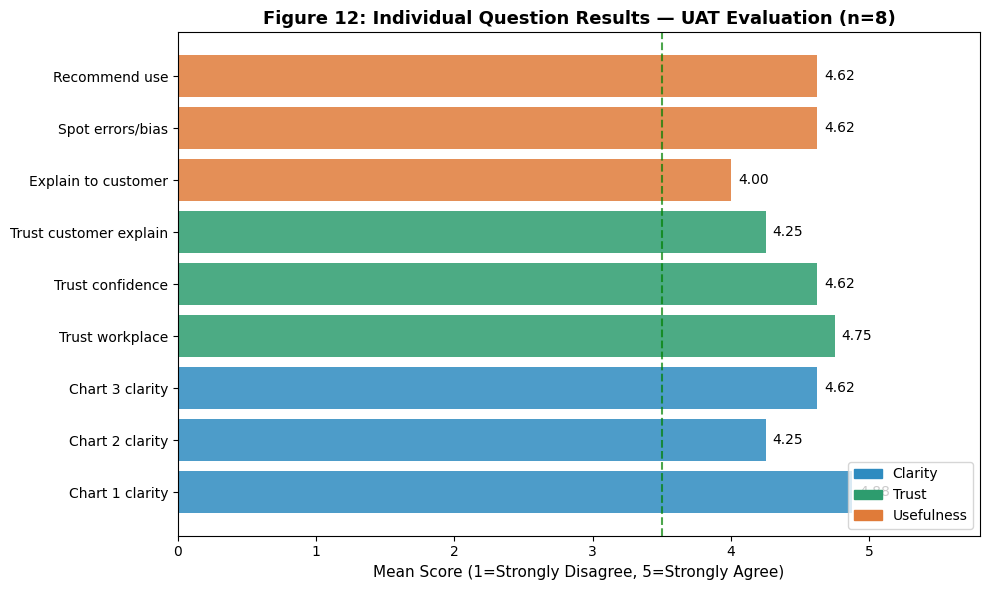

Saved: shap_plots/uat_question_heatmap.png


In [6]:
question_labels = [
    'Chart 1 clarity', 'Chart 2 clarity', 'Chart 3 clarity',
    'Trust workplace', 'Trust confidence', 'Trust customer explain',
    'Explain to customer', 'Spot errors/bias', 'Recommend use'
]

means = [clean[col].mean() for col in all_likert]
colors9 = ['#2E8BC0']*3 + ['#2D9C6E']*3 + ['#E07B39']*3

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(question_labels, means, color=colors9, alpha=0.85)

for bar, mean in zip(bars, means):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{mean:.2f}', va='center', fontsize=10)

ax.axvline(x=3.5, color='green', linestyle='--', alpha=0.7, label='Positive threshold')
ax.set_xlim(0, 5.8)
ax.set_xlabel('Mean Score (1=Strongly Disagree, 5=Strongly Agree)', fontsize=11)
ax.set_title(f'Figure 12: Individual Question Results — UAT Evaluation (n={len(clean)})',
             fontsize=13, fontweight='bold')

patches = [
    mpatches.Patch(color='#2E8BC0', label='Clarity'),
    mpatches.Patch(color='#2D9C6E', label='Trust'),
    mpatches.Patch(color='#E07B39', label='Usefulness'),
]
ax.legend(handles=patches, loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('../shap_plots/uat_question_heatmap.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: shap_plots/uat_question_heatmap.png")

In [7]:
# Adjust column indices 28, 29 to match your "useful" and "improvement" comment columns
useful_comments     = df.iloc[:, 28].dropna()
improvement_comments = df.iloc[:, 29].dropna()

print("=" * 60)
print("MOST USEFUL — PARTICIPANT COMMENTS")
print("=" * 60)
for i, c in enumerate(useful_comments, 1):
    print(f"P{i}: {c}\n")

print("=" * 60)
print("IMPROVEMENT SUGGESTIONS")
print("=" * 60)
for i, c in enumerate(improvement_comments, 1):
    print(f"P{i}: {c}\n")

with open('../reports/UAT_Open_Comments.txt', 'w', encoding='utf-8') as f:
    f.write("UAT OPEN COMMENTS\n" + "=" * 60 + "\n\n")
    f.write("MOST USEFUL:\n\n")
    for i, c in enumerate(useful_comments, 1):
        f.write(f"P{i}: {c}\n\n")
    f.write("\nIMPROVEMENT SUGGESTIONS:\n\n")
    for i, c in enumerate(improvement_comments, 1):
        f.write(f"P{i}: {c}\n\n")

print("Saved: reports/UAT_Open_Comments.txt")

MOST USEFUL — PARTICIPANT COMMENTS
P1: I found it useful to see which factors had the biggest impact on the final decision. It helped me understand why the system gave a particular result.

P2: Overall SHAP was useful because it turned a black box prediction into an explanation that can be easily understood and questioned. 

P3: The waterfall plot (Chart 1) and beeswarm plot (Chart 2) are highly useful for audit and compliance purposes. They clearly break down exactly which risk variables drove a specific decision, making it much easier to detect system bias or errors.

P4: It clearly showed which factors influenced the credit decision and whether they increased or decreased the risk.

P5: It made the models decision easier to understand by showing which factors increased or decreased the risk.

P6: They made the AI output more understandable by showing how individual factors affected the final result.

P7: They helped identify the key factors responsible for the models credit-risk p

In [8]:
clean.to_csv('../data/processed/UAT_scored.csv', index=False)
print("Saved: data/processed/UAT_scored.csv")
print(f"\nFinal summary: n={len(clean)}, Overall mean = {overall_mean:.2f}/5.00")

Saved: data/processed/UAT_scored.csv

Final summary: n=8, Overall mean = 4.51/5.00
